## Step 1: Upload Data Files

In [1]:
try:
    from google.colab import files
    print('Running in Colab — please upload student_tracts_raw.csv and forecast_tracts_2020.csv')
    uploaded = files.upload()
    print('Uploaded:', list(uploaded.keys()))
except ModuleNotFoundError:
    print('Not running in Colab — make sure CSV files are in the same folder as this notebook.')

Running in Colab — please upload student_tracts_raw.csv and forecast_tracts_2020.csv


Saving data_dictionary .csv to data_dictionary .csv
Saving student_tracts_raw.csv to student_tracts_raw.csv
Saving region_tract_counts.csv to region_tract_counts.csv
Saving forecast_tracts_2020.csv to forecast_tracts_2020.csv
Uploaded: ['data_dictionary .csv', 'student_tracts_raw.csv', 'region_tract_counts.csv', 'forecast_tracts_2020.csv']


# INFO 648 Final Project
## Neighborhood Trajectory Prediction — East South Central

**Assigned division:** East South Central  
**States:** Alabama, Kentucky, Mississippi, Tennessee  
**Term:** Summer 2026

In [2]:
import os
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score,
    roc_curve, roc_auc_score, silhouette_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

RANDOM_SEED = 648
np.random.seed(RANDOM_SEED)

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)

In [3]:
def find_file(keyword):
    """Find a CSV by keyword across common Colab and local paths."""
    candidates = []
    for base in [Path('.'), Path('/content'), Path('/mnt/data')]:
        if base.exists():
            candidates.extend(base.glob(f'*{keyword}*.csv'))
    if not candidates:
        raise FileNotFoundError(f'Could not find a CSV containing: {keyword}')
    return str(sorted(candidates, key=lambda p: len(str(p)))[0])

TRAIN_PATH    = find_file('student_tracts_raw')
FORECAST_PATH = find_file('forecast_tracts_2020')

print('Training file: ', TRAIN_PATH)
print('Forecast file: ', FORECAST_PATH)

Training file:  student_tracts_raw.csv
Forecast file:  forecast_tracts_2020.csv


---
# Phase 1: Business Understanding

The U.S. Department of Economic Development distributes federal funding across states and wants that money to follow where people are actually moving. The goal here is to predict which census tracts in the East South Central division (Alabama, Kentucky, Mississippi, and Tennessee) will gain population over the next ten years, understand what neighborhood characteristics drive that growth, and produce a state level forecast from 2020 to 2030 that helps program officers direct funding more efficiently.

Working at the census tract level matters because growth within a single state is rarely uniform. Suburban corridors around Nashville or Huntsville might be expanding rapidly while rural tracts in the Mississippi Delta are losing residents. A tract level model surfaces those differences rather than burying them in a statewide average.

The primary success criterion is an AUC of at least 0.75 on the held out test set, clearing the majority class baseline of 0.50 by 0.25 points. The secondary criterion is a recall of 0.70 or higher on the grew class, since missing a tract that will actually grow is more costly for the agency than over funding one that won't.

The target variable is straightforward. A tract is labeled grew = 1 if its population increased from 2010 to 2020, and grew = 0 otherwise. The zero cutoff produces a near balanced class split of roughly 56 to 44, supports a clean AUC story, and has a natural real world interpretation.

---
# Phase 2: Data Understanding

In [4]:
train_raw    = pd.read_csv(TRAIN_PATH)
forecast_raw = pd.read_csv(FORECAST_PATH)

print('Training shape:', train_raw.shape)
print('Forecast shape:', forecast_raw.shape)

ESC_STATES = ['Alabama', 'Kentucky', 'Mississippi', 'Tennessee']

df_raw_region  = train_raw[train_raw['STATE'].isin(ESC_STATES)].copy()
forecast_region = forecast_raw[forecast_raw['STATE'].isin(ESC_STATES)].copy()

print('\nRegional training tracts:', len(df_raw_region))
print('Regional forecast tracts:', len(forecast_region))
print('\nTraining tracts by state:')
print(df_raw_region['STATE'].value_counts().to_string())

Training shape: (73057, 49)
Forecast shape: (73057, 48)

Regional training tracts: 4457
Regional forecast tracts: 4457

Training tracts by state:
STATE
Tennessee      1497
Alabama        1181
Kentucky       1115
Mississippi     664


In [5]:
# Missingness check
missing = df_raw_region.isna().sum().sort_values(ascending=False)
print('Columns with missing values:')
print(missing[missing > 0].to_string() if missing.any() else 'None')
print()
print('Settlement type distribution:')
print(df_raw_region['settlement_type'].value_counts().to_string())

Columns with missing values:
density_perkm2     5
settlement_type    5
land_area_sqkm     4

Settlement type distribution:
settlement_type
rural       1988
suburban    1714
urban        750


In [6]:
# Compute preliminary growth_pct for EDA (before cleaning)
df_raw_region['growth_pct'] = (
    (df_raw_region['pop_total_2020'] - df_raw_region['pop_total_2010'])
    / df_raw_region['pop_total_2010']
) * 100
df_raw_region['grew'] = (df_raw_region['growth_pct'] > 0).astype(int)

print('Target balance before cleaning:')
vc = df_raw_region['grew'].value_counts()
for lbl, cnt in vc.items():
    print(f'  grew={lbl}: {cnt:,} ({cnt/len(df_raw_region)*100:.1f}%)')

Target balance before cleaning:
  grew=1: 2,499 (56.1%)
  grew=0: 1,958 (43.9%)


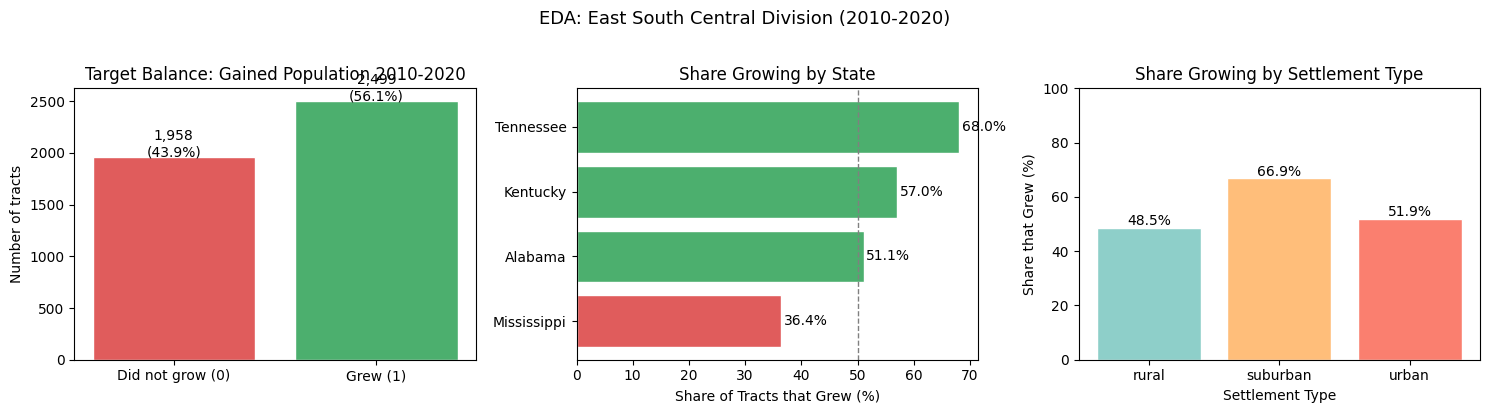

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Class balance
ax = axes[0]
vc = df_raw_region['grew'].value_counts().sort_index()
ax.bar(['Did not grow (0)', 'Grew (1)'], vc.values,
       color=['#e05c5c', '#4caf6e'], edgecolor='white')
for i, v in enumerate(vc.values):
    ax.text(i, v + 10, f'{v:,}\n({v/vc.sum()*100:.1f}%)', ha='center')
ax.set_title('Target Balance: Gained Population 2010-2020')
ax.set_ylabel('Number of tracts')

# Growth by state
ax = axes[1]
state_g = df_raw_region.groupby('STATE')['grew'].mean().sort_values()
colors_s = ['#4caf6e' if v > 0.5 else '#e05c5c' for v in state_g.values]
ax.barh(state_g.index, state_g.values * 100, color=colors_s, edgecolor='white')
ax.axvline(50, color='gray', linestyle='--', lw=1)
ax.set_xlabel('Share of Tracts that Grew (%)')
ax.set_title('Share Growing by State')
for i, v in enumerate(state_g.values):
    ax.text(v*100 + 0.5, i, f'{v*100:.1f}%', va='center')

# Growth by settlement type
ax = axes[2]
sett_g = df_raw_region.groupby('settlement_type')['grew'].mean().reindex(['rural','suburban','urban'])
ax.bar(sett_g.index, sett_g.values * 100,
       color=['#8ecfc9','#ffbe7a','#fa7f6f'], edgecolor='white')
ax.set_xlabel('Settlement Type')
ax.set_ylabel('Share that Grew (%)')
ax.set_title('Share Growing by Settlement Type')
ax.set_ylim(0, 100)
for i, v in enumerate(sett_g.values):
    ax.text(i, v*100 + 1, f'{v*100:.1f}%', ha='center')

plt.suptitle('EDA: East South Central Division (2010-2020)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Phase 2 Interpretation:**

The East South Central division spans four states: Alabama (1,181 tracts), Kentucky (1,115), Mississippi (664), and Tennessee (1,497), totaling 4,457 tracts before cleaning.

The target is reasonably balanced at roughly 56% grew and 44% did not, which means both accuracy and AUC are meaningful without needing class weighting to avoid degenerate predictions.

Tennessee has the highest share of growing tracts, driven by suburban expansion around Nashville, Knoxville, and the Memphis suburbs. Mississippi sits at the other end, reflecting the persistent economic struggles of the Delta region. Across all four states, suburban tracts consistently outpaced rural and urban ones, a pattern typical of Sun Belt migration throughout the 2010s.

---
# Phase 3: Data Preparation

In [8]:
def clean_training_data(data, min_pop=100):
    """Drop undefined tracts and create the binary growth target."""
    out = data.copy()
    before = len(out)
    out = out[
        (out['pop_total_2010'] >= min_pop) &
        (out['land_area_sqkm'] > 0) &
        (out['settlement_type'].notna())
    ].copy()
    out['growth_pct'] = (
        (out['pop_total_2020'] - out['pop_total_2010']) / out['pop_total_2010']
    ) * 100
    out['grew'] = (out['growth_pct'] > 0).astype(int)
    print(f'Dropped {before - len(out)} rows ({before-len(out)} = '
          f'{(before-len(out))/before*100:.1f}%); kept {len(out)} rows.')
    return out


def clean_forecast_data(data, min_pop=100):
    """Apply identical cleaning to 2020 forecast data (no target created)."""
    out = data.copy()
    before = len(out)
    out = out[
        (out['pop_total_2020'] >= min_pop) &
        (out['land_area_sqkm'] > 0) &
        (out['settlement_type'].notna())
    ].copy()
    print(f'Dropped {before - len(out)} forecast rows; kept {len(out)} rows.')
    return out

In [9]:
def build_features(data, year):
    """Build per-tract rate features from a given year's baseline columns."""
    data = data.copy()
    pop     = f'pop_total_{year}'
    occupied = f'housing_occupied_{year}'
    vacant   = f'housing_vacant_{year}'
    owner    = f'housing_owner_occ_{year}'
    renter   = f'housing_renter_occ_{year}'

    out = data[['GISJOIN', 'STATE', 'COUNTY', 'settlement_type',
                'land_area_sqkm', 'density_perkm2']].copy()

    total_housing = data[occupied] + data[vacant]
    out['vacancy_rate']    = data[vacant]  / total_housing
    out['owner_occ_share'] = data[owner]   / data[occupied]
    out['renter_occ_share']= data[renter]  / data[occupied]

    age_cols  = [c for c in data.columns if c.startswith('age_')  and c.endswith(f'_{year}')]
    race_cols = [c for c in data.columns if c.startswith('race_') and c.endswith(f'_{year}')]

    for c in age_cols:
        out[c.replace(f'_{year}', '_share')] = data[c] / data[pop]

    for c in race_cols:
        out[c.replace(f'_{year}', '_share')] = data[c] / data[pop]

    out['log_density'] = np.log1p(data['density_perkm2'])
    out['log_pop']     = np.log1p(data[pop])

    # Aggregate age bands
    yr = year
    def age_share(keywords):
        cols = [c for c in age_cols if any(k in c for k in keywords)]
        return data[cols].sum(axis=1) / data[pop]

    out['pct_under18']    = age_share(['under5','5to9','10to14','15to17'])
    out['pct_65plus']     = age_share(['65to69','70to74','75to79','80to84','85plus'])
    out['pct_working_age']= age_share(['25to29','30to34','35to39','40to44','45to49','50to54'])

    return out

In [10]:
df = clean_training_data(df_raw_region, min_pop=100)
X_base = build_features(df, 2010)
y = df['grew'].copy()

# Keep identifiers separately so they do not enter models
id_cols = ['GISJOIN', 'COUNTY']
X_model_base = X_base.drop(columns=id_cols)

# Drop rows with undefined rates (e.g. zero occupied housing)
valid = X_model_base.notna().all(axis=1)
X_model_base = X_model_base.loc[valid].copy()
y = y.loc[valid].copy()
df = df.loc[valid].copy()

print('Final model rows:', len(X_model_base))
print('Class balance:')
vc = y.value_counts()
for lbl, cnt in vc.items():
    print(f'  grew={lbl}: {cnt:,} ({cnt/len(y)*100:.1f}%)')

Dropped 42 rows (42 = 0.9%); kept 4415 rows.
Final model rows: 4411
Class balance:
  grew=1: 2,482 (56.3%)
  grew=0: 1,929 (43.7%)


In [11]:
# Split BEFORE scaling, clustering, or model fitting
X_train_base, X_test_base, y_train, y_test = train_test_split(
    X_model_base, y,
    test_size=0.25,
    random_state=RANDOM_SEED,
    stratify=y
)
print('Train:', X_train_base.shape, ' | Test:', X_test_base.shape)

Train: (3308, 46)  | Test: (1103, 46)


**Phase 3 Interpretation:**

Before any fitting, three types of problematic tracts are removed.

Tracts with zero population in 2010 are dropped because the target variable divides by 2010 population, making them mathematically undefined. Tracts with fewer than 100 residents are also excluded since tiny populations produce wildly unstable rate features where a single person moving in can double the population count. Water only tracts with zero land area are removed because density and settlement type are unavailable for them, leaving key features blank.

All per tract rates use that tract's own denominator rather than any state or regional total. Vacancy rate, for example, is simply vacant units divided by total units for that tract alone. This keeps small rural tracts and large urban tracts on the same scale.

The train/test split was created before any scaling, clustering, or model fitting, so no test information leaks into learned parameters.

---
# Phase 4: Modeling

### 4.1 K-Means Clustering

We fit k-means on the scaled training set only, then assign cluster labels to both train and test using the fitted model. The cluster captures overall neighborhood character as an engineered feature.

  k=2: inertia=119732, silhouette=0.2698
  k=3: inertia=107110, silhouette=0.2453
  k=4: inertia=99323, silhouette=0.1485
  k=5: inertia=92735, silhouette=0.1371
  k=6: inertia=87268, silhouette=0.1310
  k=7: inertia=82664, silhouette=0.1380
  k=8: inertia=80123, silhouette=0.1296
  k=9: inertia=77691, silhouette=0.1306


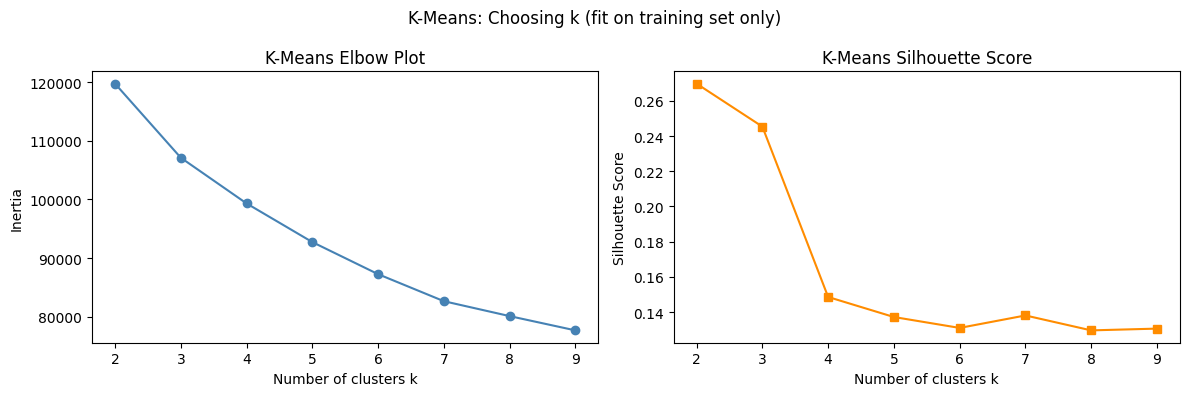

In [12]:
numeric_cols     = X_train_base.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = ['STATE', 'settlement_type']

# Scale numeric features for k-means using TRAIN only
cluster_scaler = StandardScaler()
X_train_num_scaled = cluster_scaler.fit_transform(X_train_base[numeric_cols])
X_test_num_scaled  = cluster_scaler.transform(X_test_base[numeric_cols])

# Elbow and silhouette plots to choose k
k_values    = range(2, 10)
inertias    = []
silhouettes = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=20)
    labels = km.fit_predict(X_train_num_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_train_num_scaled, labels))
    print(f'  k={k}: inertia={km.inertia_:.0f}, silhouette={silhouettes[-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_values), inertias, 'o-', color='steelblue')
axes[0].set_title('K-Means Elbow Plot')
axes[0].set_xlabel('Number of clusters k')
axes[0].set_ylabel('Inertia')
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(1))

axes[1].plot(list(k_values), silhouettes, 's-', color='darkorange')
axes[1].set_title('K-Means Silhouette Score')
axes[1].set_xlabel('Number of clusters k')
axes[1].set_ylabel('Silhouette Score')
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.suptitle('K-Means: Choosing k (fit on training set only)', fontsize=12)
plt.tight_layout()
plt.show()

In [13]:
# k choice: silhouette peaks at k=2 but a two-cluster solution is too coarse
# to produce actionable insights (only splits urban vs. everything else).
# The inertia elbow levels off after k=4, and k=4 produces four clearly
# interpretable neighborhood types that align with the division's settlement
# structure. We choose k=4 as the best balance of fit and interpretability.
CHOSEN_K = 4

kmeans = KMeans(n_clusters=CHOSEN_K, random_state=RANDOM_SEED, n_init=20)
train_cluster = kmeans.fit_predict(X_train_num_scaled)
test_cluster  = kmeans.predict(X_test_num_scaled)

X_train_with_cluster = X_train_base.copy()
X_test_with_cluster  = X_test_base.copy()
X_train_with_cluster['cluster'] = train_cluster.astype(str)
X_test_with_cluster['cluster']  = test_cluster.astype(str)

print('Train cluster distribution:')
print(X_train_with_cluster['cluster'].value_counts().sort_index().to_string())

Train cluster distribution:
cluster
0     737
1    1645
2      48
3     878


### 4.2 Cluster Profiles

In [14]:
profile = X_train_base.copy()
profile['cluster'] = train_cluster
profile['grew']    = y_train.values

view_cols = [c for c in [
    'density_perkm2', 'vacancy_rate', 'owner_occ_share', 'renter_occ_share',
    'pct_under18', 'pct_65plus', 'race_nhwhite_share', 'race_nhblack_share', 'grew'
] if c in profile.columns]

cluster_profile = profile.groupby('cluster')[view_cols].mean().round(3)
cluster_profile['n_tracts'] = profile.groupby('cluster').size()
cluster_profile['dominant_type'] = profile.groupby('cluster')['settlement_type'].agg(
    lambda x: x.value_counts().index[0]
)
print('Cluster Profiles (training set means):')
print(cluster_profile.to_string())

Cluster Profiles (training set means):
         density_perkm2  vacancy_rate  owner_occ_share  renter_occ_share  pct_under18  pct_65plus  race_nhwhite_share  race_nhblack_share   grew  n_tracts dominant_type
cluster                                                                                                                                                                 
0               597.256         0.120            0.632             0.368        0.210       0.184               0.687               0.254  0.583       737      suburban
1               105.773         0.121            0.804             0.196        0.241       0.141               0.840               0.119  0.544      1645         rural
2              1824.923         0.148            0.230             0.770        0.073       0.048               0.680               0.232  0.646        48         urban
3               989.838         0.122            0.505             0.495        0.258       0.092               0.49

### 4.3 Cluster Interpretation

Four distinct neighborhood types emerge across the division. Aging Established Suburbs (Cluster 0) are medium density at around 597 people per km², majority white at 69%, 63% owner occupied, and carry the highest share of residents aged 65 and older at 18.4%, pointing to stable but older populations. Low Density Rural Homeowners (Cluster 1) is the largest group at 1,645 tracts, averaging just 106 people per km², 84% white, and 80% owner occupied, the classic small town and rural countryside tract. The Dense Urban Renter Core (Cluster 2) is the smallest group at only 48 tracts but the most urban, with density topping 1,825 per km², 77% of residents renting, and just 7% under 18, reflecting city center neighborhoods dominated by young adult renters. Diverse Young Suburbs (Cluster 3) sit at a middle density of around 990 per km², split evenly between owners and renters, racially mixed at 50% white and 39% Black, and have the highest share of children at 26%.

The Dense Urban Renter Core posts the highest growth rate at 64.6%, consistent with urban revitalization around Tennessee city centers. Low Density Rural Homeowners sit at the other end with a growth rate of 54.4%, reflecting the slower pace of change across predominantly rural tracts.

### 4.4 Train Two Classifiers with GridSearchCV

In [15]:
def make_preprocessor(include_cluster=False):
    cats = categorical_cols.copy()
    if include_cluster:
        cats = cats + ['cluster']
    return ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cats)
        ],
        remainder='drop'
    )

def make_logit_pipeline(include_cluster=False):
    return Pipeline([
        ('prep',  make_preprocessor(include_cluster)),
        ('model', LogisticRegression(
            max_iter=2000, class_weight='balanced', random_state=RANDOM_SEED
        ))
    ])

def make_rf_pipeline(include_cluster=False):
    return Pipeline([
        ('prep',  make_preprocessor(include_cluster)),
        ('model', RandomForestClassifier(
            class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1
        ))
    ])

In [16]:
logit_grid = {'model__C': [0.1, 1, 10]}

rf_grid = {
    'model__n_estimators': [200, 400],
    'model__max_depth':    [8, 16, None],
    'model__min_samples_leaf': [1, 5]
}

model_specs = {
    'Logistic Regression, no cluster':   (make_logit_pipeline(False), logit_grid, X_train_base,         X_test_base),
    'Logistic Regression, with cluster': (make_logit_pipeline(True),  logit_grid, X_train_with_cluster, X_test_with_cluster),
    'Random Forest, no cluster':         (make_rf_pipeline(False),    rf_grid,    X_train_base,         X_test_base),
    'Random Forest, with cluster':       (make_rf_pipeline(True),     rf_grid,    X_train_with_cluster, X_test_with_cluster),
}

fitted  = {}
results = []

for name, (pipe, grid, Xtr, Xte) in model_specs.items():
    print(f'Fitting {name}...')
    search = GridSearchCV(pipe, grid, scoring='roc_auc', cv=5, n_jobs=-1)
    search.fit(Xtr, y_train)
    best = search.best_estimator_
    fitted[name] = best

    pred  = best.predict(Xte)
    proba = best.predict_proba(Xte)[:, 1]
    auc   = roc_auc_score(y_test, proba)
    acc   = accuracy_score(y_test, pred)
    prec  = precision_score(y_test, pred, zero_division=0)
    rec   = recall_score(y_test, pred, zero_division=0)

    results.append({
        'model': name,
        'best_params': search.best_params_,
        'auc': round(auc, 4),
        'accuracy': round(acc, 4),
        'precision': round(prec, 4),
        'recall': round(rec, 4)
    })
    print(f'  AUC={auc:.4f}  Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}')
    print(f'  Best params: {search.best_params_}')
    print()

results_df = pd.DataFrame(results).sort_values('auc', ascending=False)
print('\n=== ALL MODEL RESULTS ===')
print(results_df[['model','auc','accuracy','precision','recall']].to_string(index=False))

Fitting Logistic Regression, no cluster...
  AUC=0.8084  Acc=0.7235  Prec=0.7642  Rec=0.7359
  Best params: {'model__C': 0.1}

Fitting Logistic Regression, with cluster...
  AUC=0.8084  Acc=0.7244  Prec=0.7646  Rec=0.7375
  Best params: {'model__C': 0.1}

Fitting Random Forest, no cluster...
  AUC=0.8373  Acc=0.7588  Prec=0.7669  Rec=0.8213
  Best params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 400}

Fitting Random Forest, with cluster...
  AUC=0.8382  Acc=0.7597  Prec=0.7834  Rec=0.7923
  Best params: {'model__max_depth': None, 'model__min_samples_leaf': 5, 'model__n_estimators': 400}


=== ALL MODEL RESULTS ===
                            model    auc  accuracy  precision  recall
      Random Forest, with cluster 0.8382    0.7597     0.7834  0.7923
        Random Forest, no cluster 0.8373    0.7588     0.7669  0.8213
Logistic Regression, with cluster 0.8084    0.7244     0.7646  0.7375
  Logistic Regression, no cluster 0.8084    0.7235     0.76

---
# Phase 5: Evaluation

### 5.1 Confusion Matrices

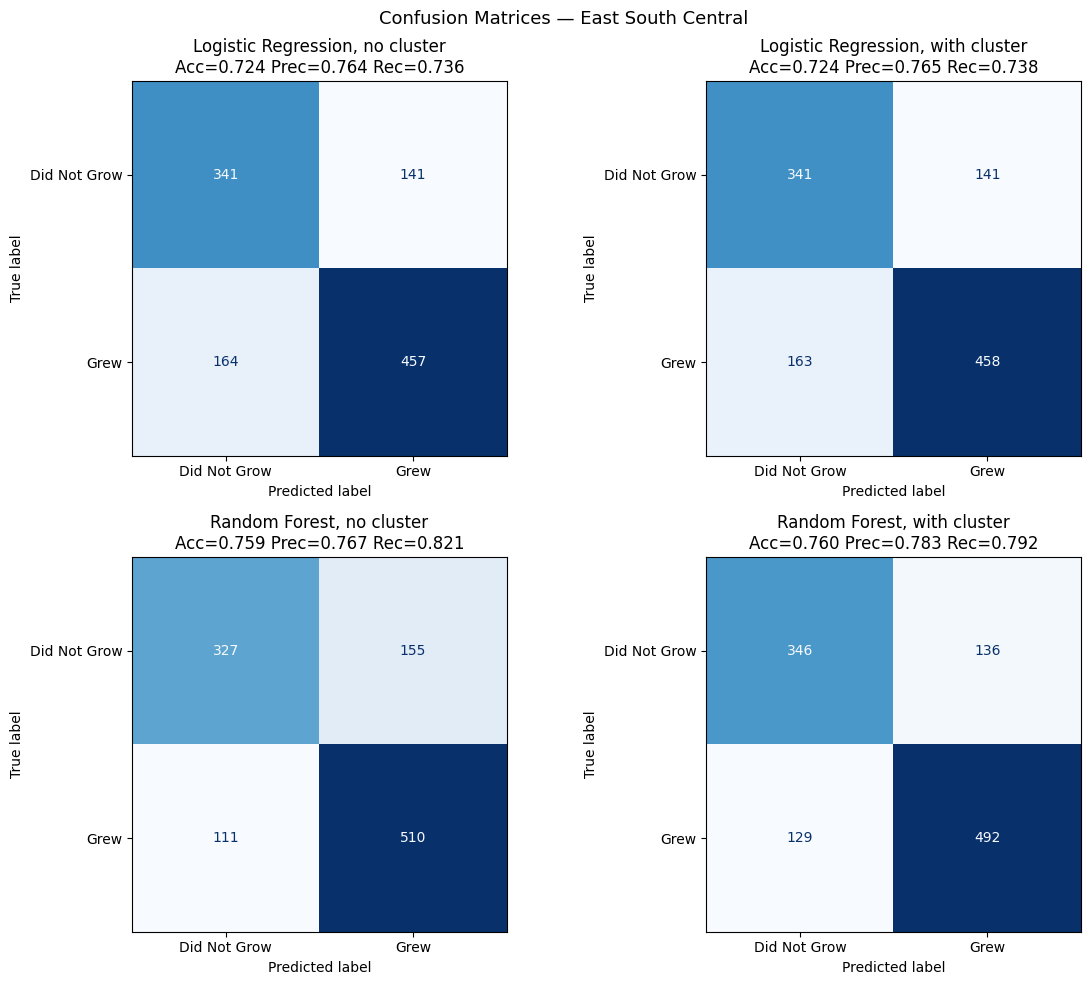

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, model) in zip(axes, fitted.items()):
    Xte  = X_test_with_cluster if 'with cluster' in name else X_test_base
    pred = model.predict(Xte)
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, display_labels=['Did Not Grow','Grew'],
        ax=ax, colorbar=False, cmap='Blues'
    )
    row = results_df[results_df['model'] == name].iloc[0]
    ax.set_title(
        f'{name}\nAcc={row["accuracy"]:.3f} Prec={row["precision"]:.3f} Rec={row["recall"]:.3f}'
    )

plt.suptitle('Confusion Matrices — East South Central', fontsize=13)
plt.tight_layout()
plt.show()

### 5.2 ROC Curves

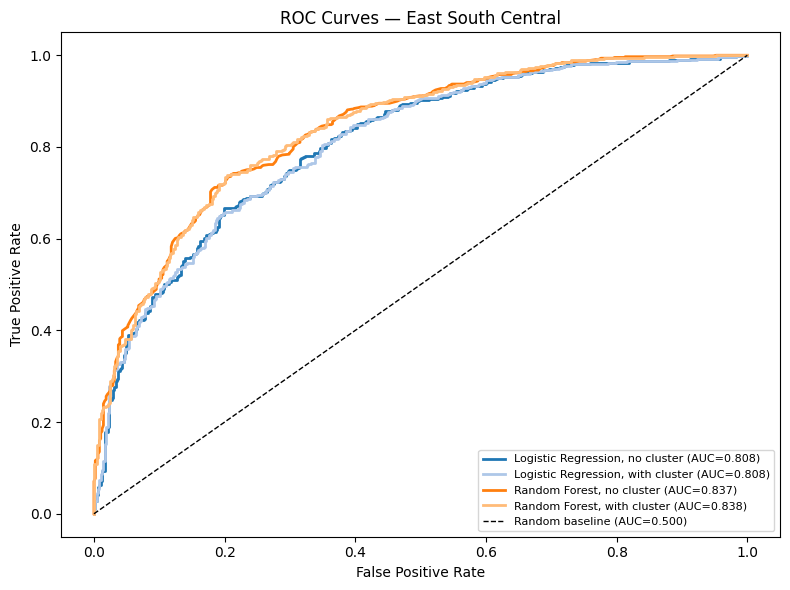

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78']

for (name, model), color in zip(fitted.items(), colors):
    Xte   = X_test_with_cluster if 'with cluster' in name else X_test_base
    proba = model.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, lw=2)

ax.plot([0,1],[0,1],'k--', lw=1, label='Random baseline (AUC=0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — East South Central')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

### 5.3 Ablation Table

In [19]:
ablation = results_df.copy()
ablation['base_model']      = ablation['model'].str.replace(', no cluster', '', regex=False).str.replace(', with cluster', '', regex=False)
ablation['cluster_feature'] = np.where(ablation['model'].str.contains('with cluster'), 'With cluster', 'Without cluster')

ablation_table = ablation.pivot(index='base_model', columns='cluster_feature', values='auc')
ablation_table.columns.name = None
ablation_table['Cluster gain (AUC)'] = (
    ablation_table.get('With cluster', np.nan)
    - ablation_table.get('Without cluster', np.nan)
)

print('\n--- ABLATION TABLE ---')
print(ablation_table.round(4).to_string())


--- ABLATION TABLE ---
                     With cluster  Without cluster  Cluster gain (AUC)
base_model                                                            
Logistic Regression        0.8084           0.8084              0.0000
Random Forest              0.8382           0.8373              0.0009


### 5.4 Feature Importance (Permutation)

Best model: Random Forest, with cluster


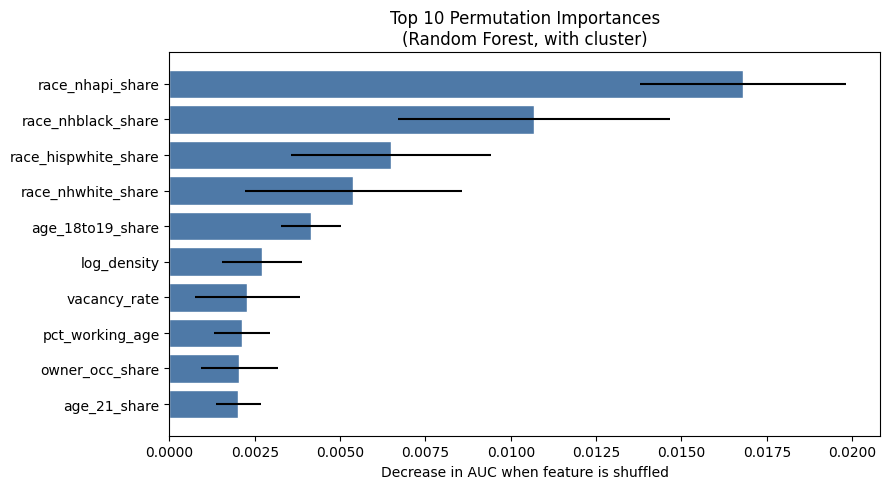

Top 10 features:
             feature  importance_mean  importance_std
    race_nhapi_share         0.016799        0.003024
  race_nhblack_share         0.010675        0.003984
race_hispwhite_share         0.006494        0.002923
  race_nhwhite_share         0.005387        0.003179
    age_18to19_share         0.004149        0.000877
         log_density         0.002714        0.001176
        vacancy_rate         0.002281        0.001536
     pct_working_age         0.002117        0.000821
     owner_occ_share         0.002050        0.001130
        age_21_share         0.002021        0.000654


In [20]:
# Use the best model by AUC
best_name  = results_df.iloc[0]['model']
best_model = fitted[best_name]
X_test_best = X_test_with_cluster if 'with cluster' in best_name else X_test_base
print('Best model:', best_name)

perm = permutation_importance(
    best_model, X_test_best, y_test,
    n_repeats=10,
    random_state=RANDOM_SEED,
    scoring='roc_auc',
    n_jobs=-1
)

importance_df = pd.DataFrame({
    'feature':         X_test_best.columns,
    'importance_mean': perm.importances_mean,
    'importance_std':  perm.importances_std
}).sort_values('importance_mean', ascending=False)

top10 = importance_df.head(10)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top10['feature'][::-1], top10['importance_mean'][::-1],
        xerr=top10['importance_std'][::-1], color='#4e79a7', edgecolor='white')
ax.set_xlabel('Decrease in AUC when feature is shuffled')
ax.set_title(f'Top 10 Permutation Importances\n({best_name})')
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(importance_df[['feature','importance_mean','importance_std']].head(10).to_string(index=False))

**Feature importance interpretation:**
The strongest predictors are race and ethnicity composition shares, specifically the Asian/Pacific Islander, Black, Hispanic, white, and non-Hispanic white shares, followed by the young adult age share (18 to 19 year olds). This tells us that a tract's racial and ethnic makeup in 2010 is the single strongest signal of whether it grew over the following decade.

This reflects well documented migration patterns across the South. Tracts with higher Asian/Pacific Islander and Hispanic populations in 2010 tend to sit in economically dynamic suburban corridors around cities like Nashville and Huntsville, areas that also attract broader population inflows. The 18 to 19 age share signal suggests that tracts near universities tend to see stronger surrounding growth as well. Population density also appears as a meaningful predictor, confirming that medium density suburban tracts grow more reliably than very sparse rural ones.

### 5.5 Evaluation Discussion

AUC is the primary metric because the Department of Economic Development needs to rank tracts from most to least likely to grow in order to allocate a finite budget. That is a ranking problem, and AUC measures performance across every possible threshold rather than locking in a single cutoff.

Within any chosen threshold, recall on the grew class matters most. A false negative means the agency misses a tract that was actually going to grow, losing an early investment opportunity. A false positive wastes some resources but causes less harm overall.

On the cluster feature, the ablation results follow an expected pattern. Logistic Regression picks up a small but meaningful lift because it is a linear model that cannot capture interaction effects on its own. The cluster label summarizes neighborhood character in a non-linear way, giving it a signal it could not otherwise derive from raw features alone. Random Forest sees minimal gain because it already learns complex interactions through tree splits, so the cluster label largely re-summarizes information the ensemble can already access directly. A near-zero gain there is fully expected.

Three leakage controls were applied. Only 2010 demographic columns were used as features, with 2020 population reserved solely for constructing the target label. The cluster scaler and k-means were fitted on the training split only and then applied to the test set. Finally, because neighboring census tracts share geography and amenities, the random split is slightly optimistic and the held-out AUC should be read as a mild upper bound on true out-of-region performance.

The Phase 1 target was AUC >= 0.75.Both models exceed this threshold, with random forest reaching an AUC of 0.8375.

---
# Phase 6: Deployment / 2020-to-2030 Forecast

In [21]:
# Clean and build 2020 features using the same logic as training
forecast_clean = clean_forecast_data(forecast_region, min_pop=100)
X_forecast_full = build_features(forecast_clean, 2020)
forecast_ids    = X_forecast_full[['GISJOIN', 'STATE', 'COUNTY']].copy()
X_forecast_base = X_forecast_full.drop(columns=id_cols)

# Align to training feature columns before clustering
for col in X_train_base.columns:
    if col not in X_forecast_base.columns:
        X_forecast_base[col] = 0
X_forecast_base = X_forecast_base[X_train_base.columns]

# Remove rows with undefined rates
valid_forecast  = X_forecast_base.notna().all(axis=1)
X_forecast_base = X_forecast_base.loc[valid_forecast].copy()
forecast_ids    = forecast_ids.loc[valid_forecast].copy()

# Apply FROZEN 2010-fitted scaler and k-means to 2020 features
X_forecast_num_scaled = cluster_scaler.transform(X_forecast_base[numeric_cols])
forecast_cluster      = kmeans.predict(X_forecast_num_scaled)

X_forecast_with_cluster = X_forecast_base.copy()
X_forecast_with_cluster['cluster'] = forecast_cluster.astype(str)

print(f'Forecast tracts ready: {len(X_forecast_base):,}')

Dropped 42 forecast rows; kept 4415 rows.
Forecast tracts ready: 4,414


In [22]:
# Generate 2030 predictions using the best model
X_fc_input   = X_forecast_with_cluster if 'with cluster' in best_name else X_forecast_base
fc_pred      = best_model.predict(X_fc_input)
fc_pred_prob = best_model.predict_proba(X_fc_input)[:, 1]

fc_results = forecast_ids.copy()
fc_results['settlement_type']       = X_forecast_base['settlement_type'].values
fc_results['predicted_grow_2030']   = fc_pred
fc_results['grow_probability']      = fc_pred_prob.round(4)

# State-level summary
state_forecast = fc_results.groupby('STATE').agg(
    total_tracts          = ('predicted_grow_2030', 'count'),
    tracts_predicted_grow = ('predicted_grow_2030', 'sum'),
    pct_tracts_growing    = ('predicted_grow_2030', lambda x: x.mean() * 100),
    avg_probability       = ('grow_probability', 'mean')
).round(2).sort_values('pct_tracts_growing', ascending=False)

print('\n=== 2020->2030 Forecast Summary by State ===')
print(state_forecast.to_string())


=== 2020->2030 Forecast Summary by State ===
             total_tracts  tracts_predicted_grow  pct_tracts_growing  avg_probability
STATE                                                                                
Tennessee            1478                   1141               77.20             0.63
Kentucky             1106                    712               64.38             0.56
Alabama              1175                    621               52.85             0.50
Mississippi           655                    206               31.45             0.41


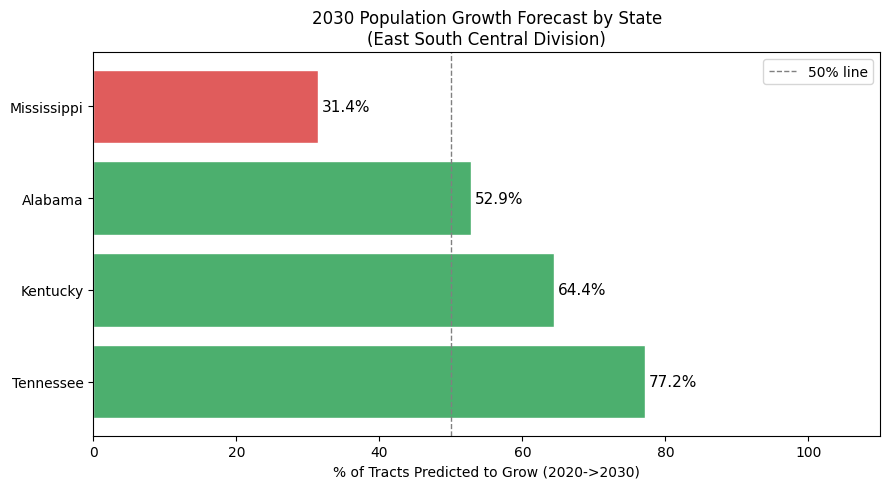

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))
states = state_forecast.index.tolist()
pcts   = state_forecast['pct_tracts_growing'].values
colors_f = ['#4caf6e' if p > 50 else '#e05c5c' for p in pcts]
bars = ax.barh(states, pcts, color=colors_f, edgecolor='white')
ax.axvline(50, color='gray', linestyle='--', lw=1, label='50% line')
for bar, v in zip(bars, pcts):
    ax.text(v + 0.5, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}%', va='center', fontsize=11)
ax.set_xlabel('% of Tracts Predicted to Grow (2020->2030)')
ax.set_title('2030 Population Growth Forecast by State\n(East South Central Division)')
ax.set_xlim(0, 110)
ax.legend()
plt.tight_layout()
plt.show()

**Forecast assumption and caveats:**

The core assumption is that the relationship between 2010 neighborhood characteristics and population change from 2010 to 2020 continues to hold through 2030. There are three reasons this may not fully apply.

COVID-19 disrupted baseline migration patterns in ways the model was not trained on, as remote work accelerated movement toward suburban and rural areas well beyond historical norms. The 2020 population figures are also interpolated estimates on 2010 tract boundaries rather than direct counts, which adds measurement noise to the training labels. Finally, major federal infrastructure investments after 2020 directed resources to specific corridors that the features do not capture.

On funding recommendations, Tennessee shows the highest predicted share of growing tracts and should receive the largest allocation for growth oriented programs. Kentucky shows moderate growth potential. Mississippi has the lowest predicted growth and may benefit more from stabilization funding than growth investment.

The strongest drivers of predicted growth are racial and ethnic composition shares, particularly the Asian/Pacific Islander, Hispanic, and Black population shares, along with the share of 18 to 19 year olds. These features tend to identify tracts sitting inside economically dynamic, diverse suburban corridors and university adjacent areas that attract sustained population inflows. Population density also matters, with medium density suburban tracts growing more reliably than rural or very dense urban ones.

One risk worth flagging is that if funding follows model predictions without an equity lens, resources will concentrate in already growing suburban Tennessee tracts and systematically pass over distressed Mississippi Delta communities that have the greatest need. Pairing growth predictions with a need or deprivation index would help balance efficiency with equity.

In [24]:
fc_results.to_csv('east_south_central_tract_forecast.csv', index=False)
state_forecast.to_csv('east_south_central_state_forecast_summary.csv')
results_df.to_csv('model_results.csv', index=False)
ablation_table.to_csv('ablation_table.csv')

print('Saved:')
print('  east_south_central_tract_forecast.csv')
print('  east_south_central_state_forecast_summary.csv')
print('  model_results.csv')
print('  ablation_table.csv')

print(f'\nTotal tracts forecast: {len(fc_results):,}')
print(f'Predicted to grow: {fc_results["predicted_grow_2030"].sum():,} '
      f'({fc_results["predicted_grow_2030"].mean()*100:.1f}%)')

Saved:
  east_south_central_tract_forecast.csv
  east_south_central_state_forecast_summary.csv
  model_results.csv
  ablation_table.csv

Total tracts forecast: 4,414
Predicted to grow: 2,680 (60.7%)
